# **Titanic Chido**

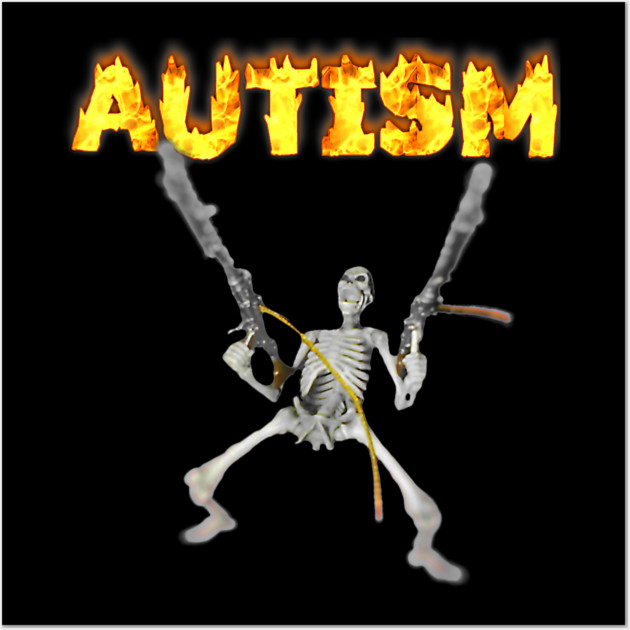

# 1. Carga de datos chida del dataset 💯

In [2]:
import pandas as pd

datos = pd.read_csv('train.csv')

In [3]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 2.Exploracion de los datos chida del Titanic ✈

<Axes: xlabel='Survived', ylabel='count'>

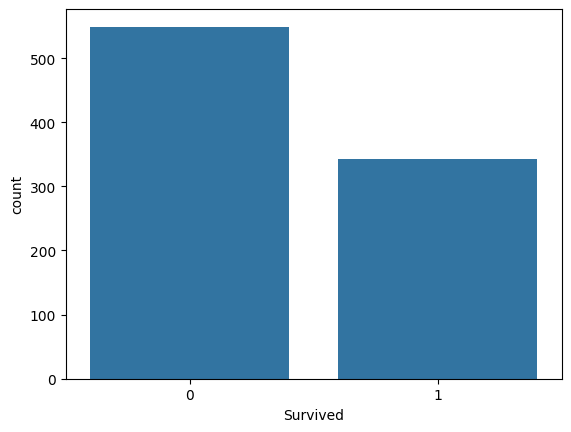

In [5]:
import seaborn as sb

sb.countplot(x="Survived", data=datos)

<Axes: xlabel='Survived', ylabel='count'>

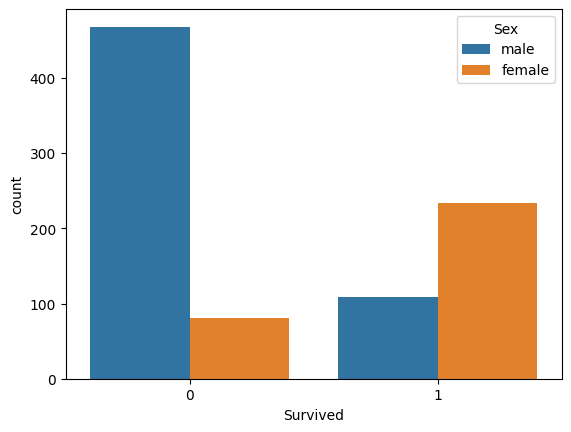

In [6]:
sb.countplot(x="Survived", data=datos, hue="Sex")

# 3.Limpieza chida y Preprocesamiento chido de los datos 🐢

In [8]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


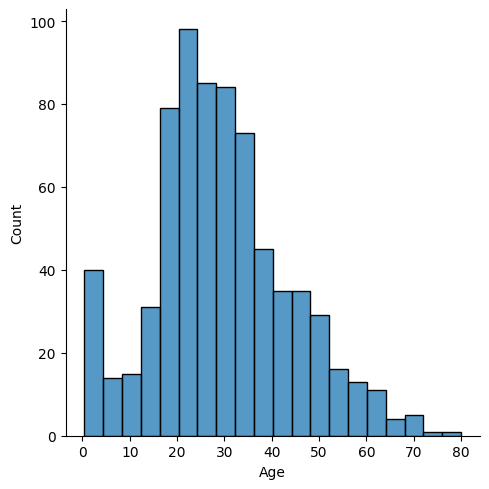

In [9]:
sb.displot(x="Age", data=datos)

In [10]:
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [11]:
datos["Age"].mean()

np.float64(29.69911764705882)

In [12]:
datos["Age"].fillna(datos["Age"].mean())

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [14]:
datos["Age"] = datos["Age"].fillna(datos["Age"].mean())

In [15]:
datos["Age"]


,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [21]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [17]:
datos = datos.drop(["Cabin"], axis=1)

In [19]:
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [20]:
datos = datos.dropna()

In [33]:
datos.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [23]:
datos = datos.drop(["Name", "PassengerId", "Ticket"], axis=1)

# 4.Preparacion del modelo chida ☕

In [27]:
dummies_sex = pd.get_dummies(datos["Sex"], drop_first=True)

In [28]:
datos = datos.join(dummies_sex)
datos = datos.drop(["Sex"], axis=1)

<Axes: xlabel='Survived', ylabel='count'>

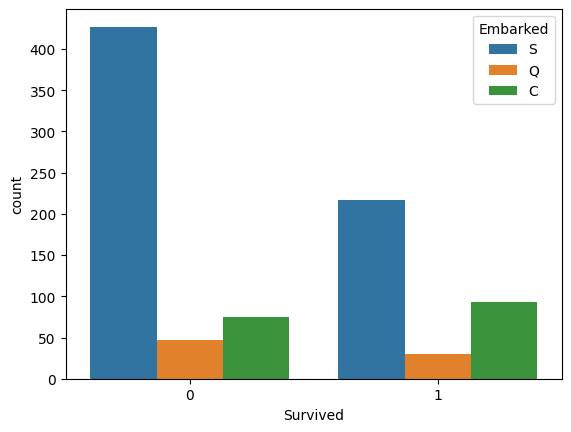

In [30]:
sb.countplot(x="Survived", data=datos, hue="Embarked")

In [31]:
dummies_embarked = pd.get_dummies(datos["Embarked"], drop_first=True)

In [32]:
datos = datos.join(dummies_embarked)
datos = datos.drop(["Embarked"], axis=1)

<Axes: >

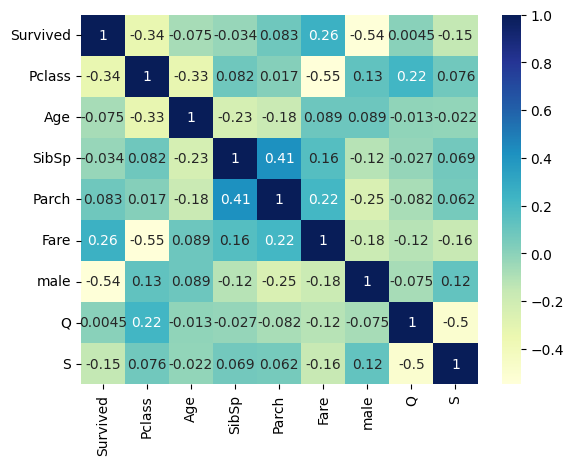

In [37]:
sb.heatmap(datos.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='Survived', ylabel='count'>

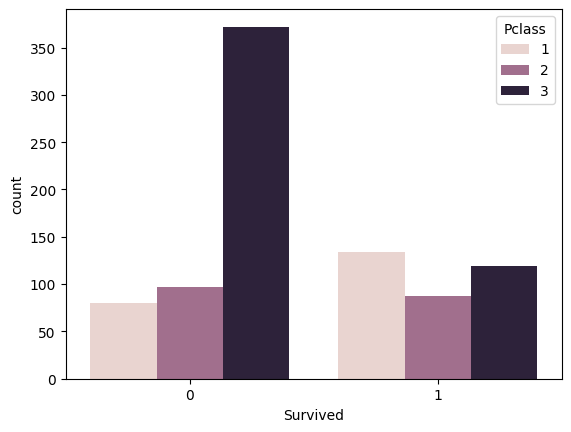

In [38]:
sb.countplot(x="Survived", data=datos, hue="Pclass")

In [39]:
x = datos.drop(["Survived"], axis=1)
y = datos["Survived"]

In [40]:
from sklearn.model_selection import train_test_split

x_ent, x_pru, y_ent, y_pru = train_test_split(x, y, test_size=.2)

# 5.Evaluacion y Entretamiento chido 🤖

In [41]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)
modelo.fit(x_ent, y_ent)

LogisticRegression(max_iter=1000)

In [42]:
predicciones = modelo.predict(x_pru)

In [43]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru, predicciones)

0.7808988764044944

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83       114
           1       0.69      0.72      0.70        64

    accuracy                           0.78       178
   macro avg       0.76      0.77      0.76       178
weighted avg       0.78      0.78      0.78       178



In [45]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_pru, predicciones)

array([[93, 21],
       [18, 46]])

In [46]:
pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["Pred: No", "Pred: Si"], index=["Real: No", "Real: Si"])

,Pred: No,Pred: Si
Real: No,93,21
Real: Si,18,46


In [47]:
x.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [49]:
np = [3, 35, 0, 0, 10, 1, 0, 0]
prediccion = modelo.predict([np])
if prediccion[0] == 1:
    print("Sobreviviste")
else:
    print("No Sobreviviste :(")

No Sobreviviste :(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
